## Analyzing Completed Simulations
Dan Chen, Summer 2026

### Imports

In [699]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import pickle as pkl

from astropy import units as u
from pathlib import Path
from collections import defaultdict
from fractions import Fraction

import mmr_id
import rebound_sims as reb_sims

import warnings
warnings.filterwarnings('ignore')
def plot_prettier(dpi=200, fontsize=8, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

### Investigate a specific simulation run & plot its orbital evolution

Dataset 7, Sim 114
num_pl: 3, num_em: 10, num_ptsml: 100
Sigma_1au: 5736 g/cm^2, h_1au: 0.024, beta: 0


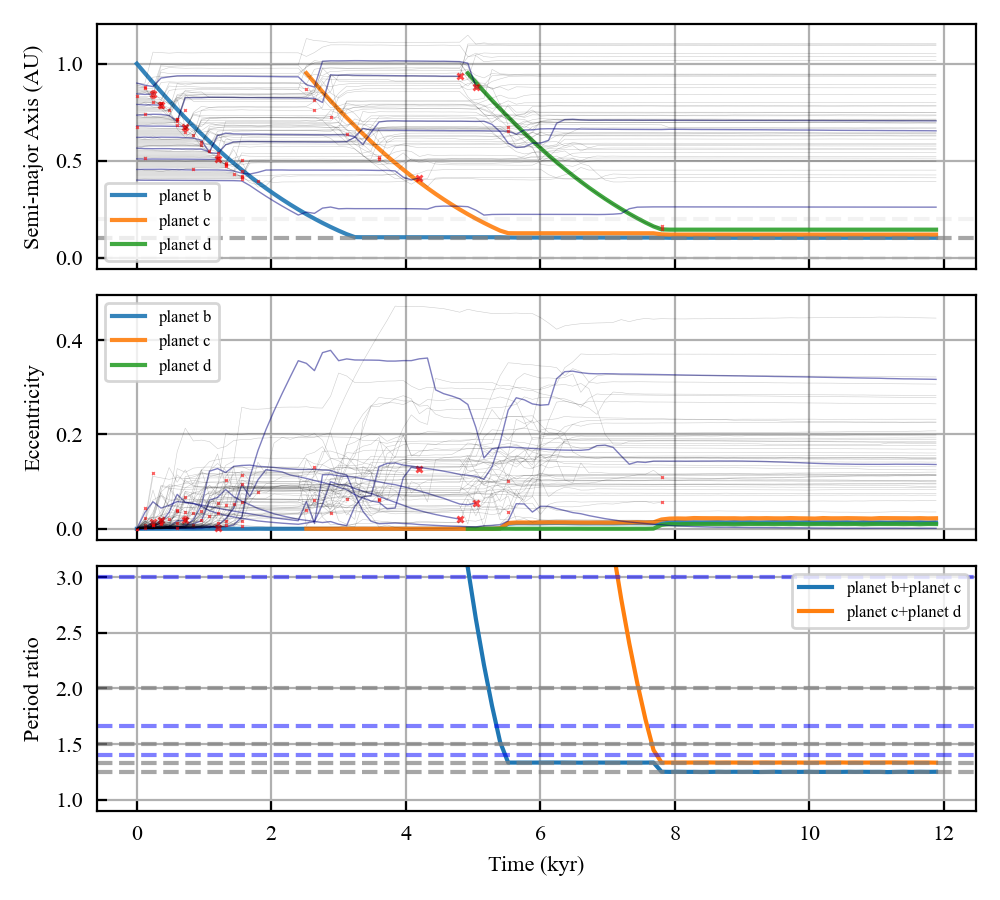

In [698]:
%matplotlib widget

def plot_system(saved_sim, elements, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    
    # Function to plot collision markers
    def plot_end_marker(ax, t, y, **kwargs):
        y = np.asarray(y)

        # Find valid entries
        valid = np.isfinite(y)

        # Only plot marker if the object disappears before the end
        if np.any(valid) and not valid[-1]:
            last_idx = np.where(valid)[0][-1]

            ax.plot(
                t[last_idx],
                y[last_idx],
                marker='x',
                linestyle='None',
                **kwargs
            )
    
    # could also try plotting log
    sim_data, metadata = saved_sim
    rock_names = list(sim_data.keys())
    times = sim_data[rock_names[0]]['time']
    
    fig, axs = plt.subplots(len(elements), 1, sharex=True)
    fig.set_figwidth(5)
    fig.set_figheight(1.5*len(elements))

    time_factor = {'yr': 1, 'kyr': 1e3, 'Myr': 1e6}[t_units]
    pl_style = {'alpha': 0.9}
    em_style = {'c': 'navy', 'alpha': 0.5, 'lw': 0.5}
    ptsml_style = {'c': 'k', 'alpha': 0.2, 'lw': 0.2}

    for i, ax in enumerate(axs):
        if elements[i] == 'a':
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot((times/time_factor)[:], sim_data[name]["a"][:], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["a"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["a"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], color='r', ms=1, mew=0.5, alpha=0.6)
            
            # Plot ide location & width
            try:
                ax.axhline(metadata["ide_position"], color='gray', ls='--', alpha=0.7)
                ax.axhline(metadata["ide_position"] - metadata["ide_width"], color='gray', ls='--', alpha=0.1)
                ax.axhline(metadata["ide_position"] + metadata["ide_width"], color='gray', ls='--', alpha=0.1)
            except:
                pass
            
            ax.set_ylabel("Semi-major Axis (AU)")
            # ax.set_ylim(-0.1,1.15)
            
        elif elements[i] == "e":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["e"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["e"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["e"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel("Eccentricity")
            
        elif elements[i] == 'P_ratio':
            for i in range(num_pl):
                name = rock_names[i]
                if i < num_pl-1:
                    ax.plot(times/time_factor, sim_data[rock_names[i+1]]["P"]/sim_data[name]["P"], label=f"{name}+{rock_names[i+1]}")
            
            # Add horizontal lines for resonances
            first_res = [2/1, 3/2, 4/3, 5/4]
            second_res = [3/1, 5/3, 7/5]
            third_res = [4/1, 5/2, 7/4, 8/5]
    
            for r in first_res:
                ax.axhline(r, color='gray', ls='--', alpha=0.7)
            for r in second_res:
                ax.axhline(r, color='blue', ls='--', alpha=0.5)
            # for r in third_res:
            #     ax3.axhline(r, color='red', ls='--', alpha=0.5)
            
            ax.set_ylabel("Period ratio")
            ax.set_ylim(0.9,3.1)

        elif elements[i] == "inc":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["inc"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["inc"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["inc"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel("Inclination")
        
        elif elements[i] == "pomega":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel(r"$\varpi$")
            
    axs[-1].set_xlabel("Time (kyr)")
    for ax in axs:
        ax.legend(fontsize=6)
        ax.grid(True)

    fig.subplots_adjust(hspace=0)

    # plt.suptitle("Orbital Evolution")
    plt.tight_layout(); plt.show()
    # plt.savefig("orbital_evo.svg", bbox_inches="tight")

dataset_id = 7
sim_id = 114

for sim_id in range(sim_id, sim_id+1):
# for sim_id in inside_d:
    base_dir = Path.cwd()
    file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"

    try:
        saved_sim = reb_sims.load_simulation_run(file_path)
    except FileNotFoundError:
        print(f"Sim {sim_id} not found")
        continue

    sim_data, metadata = saved_sim
    m_star = metadata['m_star'] 
    rock_names = list(sim_data.keys())
    rocks = {p: sim_data[p] for p in rock_names}
    num_pl, num_em, num_ptsml = metadata['num_pl'], metadata['num_em'], metadata['num_ptsml']

    print(f"Dataset {dataset_id}, Sim {sim_id}")    
    print(f"num_pl: {metadata['num_pl']}, num_em: {metadata['num_em']}, num_ptsml: {metadata['num_ptsml']}") 
    print(f"Sigma_1au: {metadata['Sigma_1au']:.0f} g/cm^2, h_1au: {metadata['h_1au']:.3f}, beta: {metadata['beta']}")
    plot_system(saved_sim, ['a', 'e', 'P_ratio'], num_pl, num_em, num_ptsml)
    

### Obtain planet outcomes (survival, resonance, libration)

In [554]:
# Get planet outcomes for all sims in one dataset
def classify_resonance(P_ratio, librates):
    """Classify first-order resonances of simulations up to 7:6. 
    If planets are not librating, the result will be "not in resonance".
    If planets are in higher-order or higher-index resonance, the result
    will be "other".


    Args:
        P_ratio (float): (Assigned) period ratio.
        librates (bool): Whether resonant angle librates.

    Returns:
        Classification of the resonance.
    """    


    if not librates or np.isnan(P_ratio):
        return "not in resonance"

    resonances = {
        "2:1": 2/1,
        "3:2": 3/2,
        "4:3": 4/3,
        "5:4": 5/4,
        "6:5": 6/5,
        "7:6": 7/6
    }

    for name, ratio in resonances.items():
        if P_ratio == ratio:
            return name

    return "other"

def get_planet_outcomes(dataset_id, num_sims, pomega='mixed', amp_threshold=90):
    rows = []
    base_dir = Path.cwd()
    for sim_id in range(num_sims):
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
        
        # Check planet survival
        alive_planets = []
        for name in ['planet b', 'planet c', 'planet d'][:metadata['num_pl']]:
            if not np.isnan(sim_data[name]['a'].iloc[-1]):
                alive_planets.append(name)

        # Check both pairs if all planets are alive
        if len(alive_planets) == 3:
            c = alive_planets[1]; d = alive_planets[2]
            
            # Get P_ratios by direct division
            true_outer_P_ratio = sim_data[d]['P'].iloc[-1]/sim_data[c]['P'].iloc[-1]
            
            # Swap planets if inner became outer
            if true_outer_P_ratio < 1:
                c, d = d, c
                true_outer_P_ratio = 1/true_outer_P_ratio
            
            # Check Delta (find p, q such that Delta is closest to 0)
            outer_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[c], sim_data[d])
            outer_P_ratio = outer_best[0]/outer_best[1]
            outer_Delta = true_outer_P_ratio/outer_P_ratio - 1
            
            # Check libration of 2BR angle
            outer_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[c], sim_data[d], pomega=pomega, amp_threshold=amp_threshold) != (0,0))
        
        else:
            outer_P_ratio = np.nan
            true_outer_P_ratio = np.nan
            outer_Delta = np.nan
            outer_librates = False
        
        # Check ratio of remaining pair, call it inner pair
        if len(alive_planets) >=2:
            b = alive_planets[0]; c = alive_planets[1] # this will be the right pair regardless
                
            # Get P_ratios by direct division
            true_inner_P_ratio = sim_data[c]['P'].iloc[-1]/sim_data[b]['P'].iloc[-1]
            
            # Swap planets if inner became outer
            if true_inner_P_ratio < 1:
                b, c = c, b
                true_inner_P_ratio = 1/true_inner_P_ratio
                
            # Check Delta (find p, q such that Delta is closest to 0)
            inner_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[b], sim_data[c])
            inner_P_ratio = inner_best[0]/inner_best[1]
            inner_Delta = true_inner_P_ratio/inner_P_ratio - 1
            
            # Check libration of 2BR angle
            inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[b], sim_data[c], pomega=pomega, amp_threshold=amp_threshold) != (0,0))

        else:
            inner_P_ratio = np.nan
            true_inner_P_ratio = np.nan
            inner_Delta = np.nan
            inner_librates = False
        
        if len(alive_planets) >= 1:
            m_pl = metadata['m_vals'][0]
            a = metadata['ide_position']
            P = a**(3/2)
            Sigma = metadata['Sigma_1au']*AU**2 / Msun * a**-metadata['alpha']
            h = metadata['h_1au'] * a**metadata['beta']
            tau_a = 1/(2.7+1.1*metadata['alpha']) / m_pl / (Sigma * a**2) * h**2 / (2*np.pi / P) # Evaluated at IDE
        else:
            tau_a = np.nan
            
        log_tau_Omega = np.log10(tau_a * 2*np.pi / (metadata['ide_position']**(3/2)))

        # Create df to store data
        Sigma_1au = metadata['Sigma_1au']
        h_1au = metadata['h_1au']
        
        rows.append({
            "sim_id": sim_id,
            "Sigma_1au": Sigma_1au,
            "h_1au": h_1au,
            "alive_planets": alive_planets,
            "inner_P_ratio": inner_P_ratio,
            "outer_P_ratio": outer_P_ratio,
            "true_inner_P_ratio": round(true_inner_P_ratio, 3),
            "true_outer_P_ratio": round(true_outer_P_ratio, 3),
            "inner_P_Delta (%)": round(inner_Delta*100, 1),
            "outer_P_Delta (%)": round(outer_Delta*100, 1),
            "inner_librates": inner_librates,
            "outer_librates": outer_librates,
            "inner_res_class": classify_resonance(inner_P_ratio, inner_librates),
            "outer_res_class": classify_resonance(outer_P_ratio, outer_librates),
            "pl_survived": len(alive_planets),
            "tau_a (kyr)": tau_a/1000,
            "log_tau_Omega": round(log_tau_Omega, 5), # prevent errors in plotting
        })
        
    outcomes = pd.DataFrame(rows)
    return outcomes

dataset_id = 6
planet_outcomes = get_planet_outcomes(dataset_id=dataset_id, num_sims=900, pomega='mixed', amp_threshold=90)
planet_outcomes.to_hdf(f"dfs/planet_outcomes{dataset_id}.h5", key="df", mode="w") # Save to disk

In [506]:
# base_dir = Path.cwd()
# dataset_id=7
# missing = [
#     sim_id
#     for sim_id in range(900)
#     if not (base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5").exists()
# ]
# print(len(missing))
# def format_ranges(nums):
#     if not nums:
#         return ""

#     nums = sorted(nums)
#     ranges = []

#     start = end = nums[0]

#     for n in nums[1:]:
#         if n == end + 1:
#             end = n
#         else:
#             if start == end:
#                 ranges.append(f"{start}")
#             else:
#                 ranges.append(f"{start}-{end}")
#             start = end = n

#     # Add the last range
#     if start == end:
#         ranges.append(f"{start}")
#     else:
#         ranges.append(f"{start}-{end}")

#     return ",".join(ranges)
# format_ranges(missing)

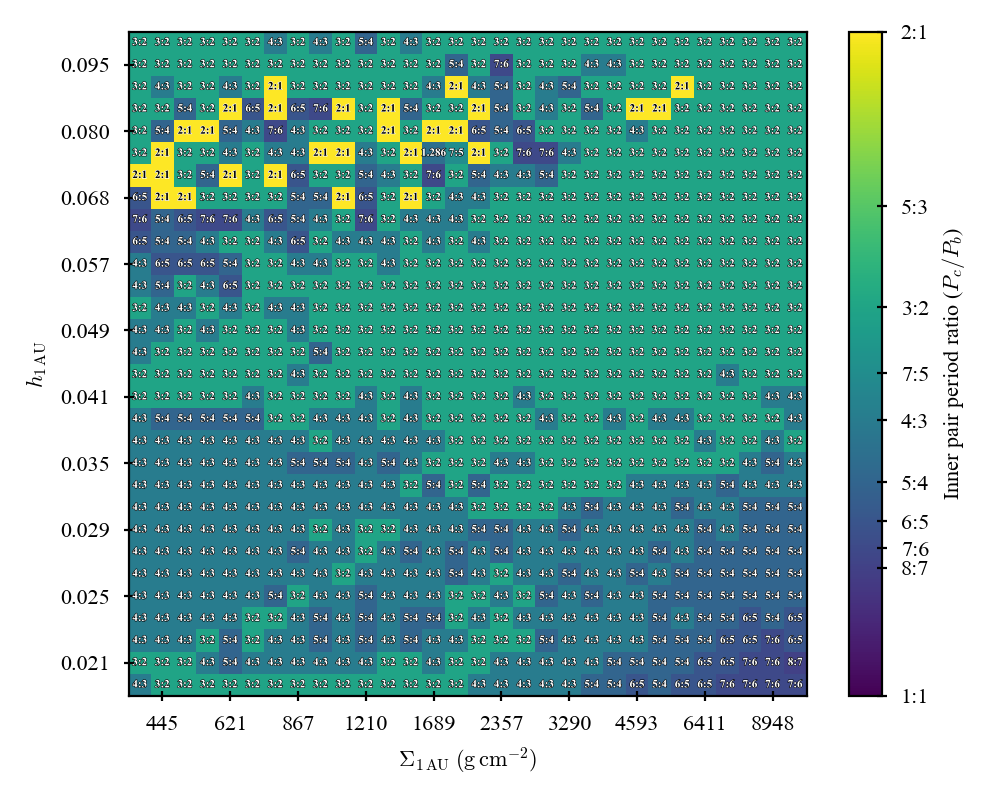

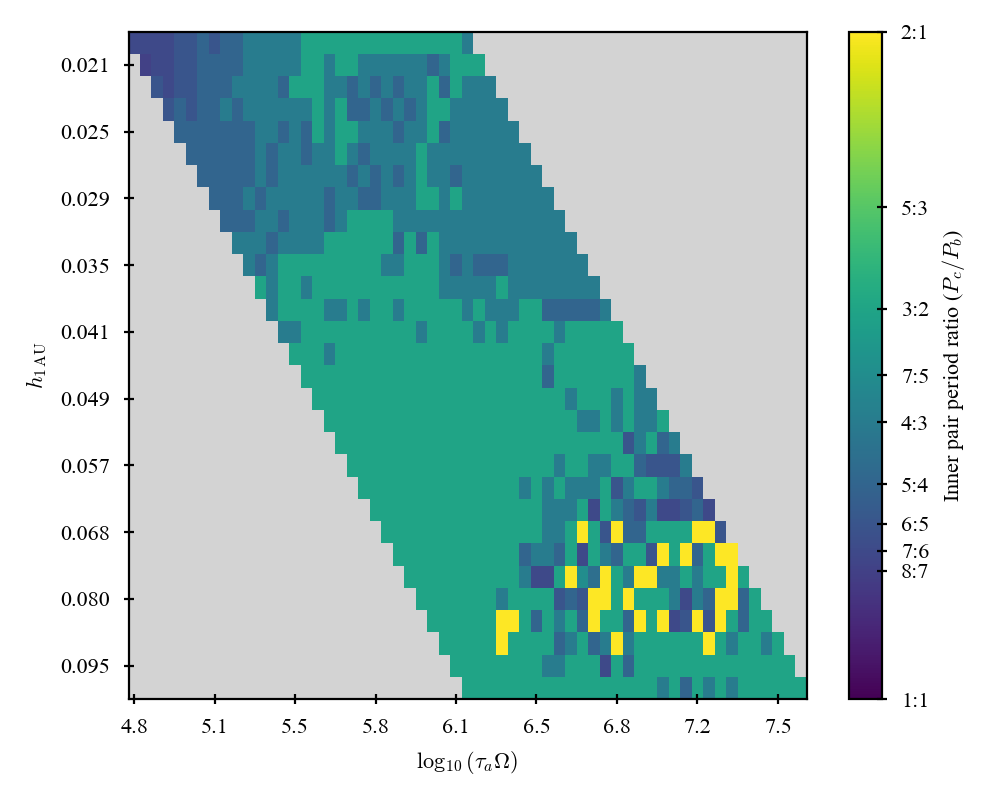

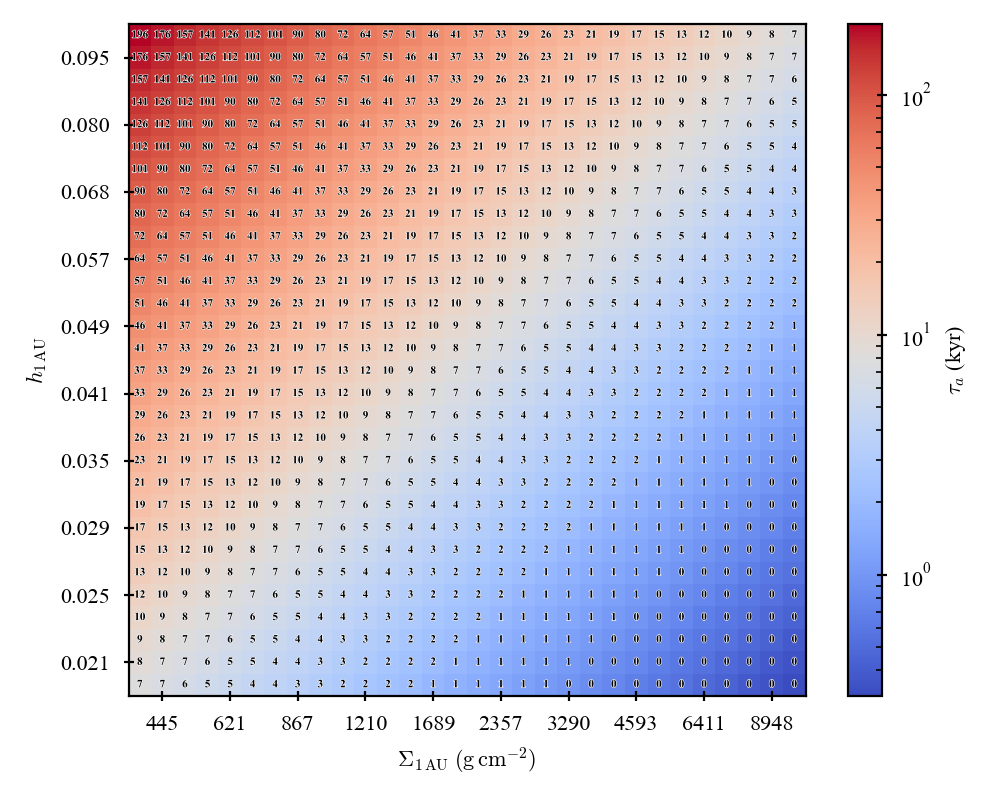

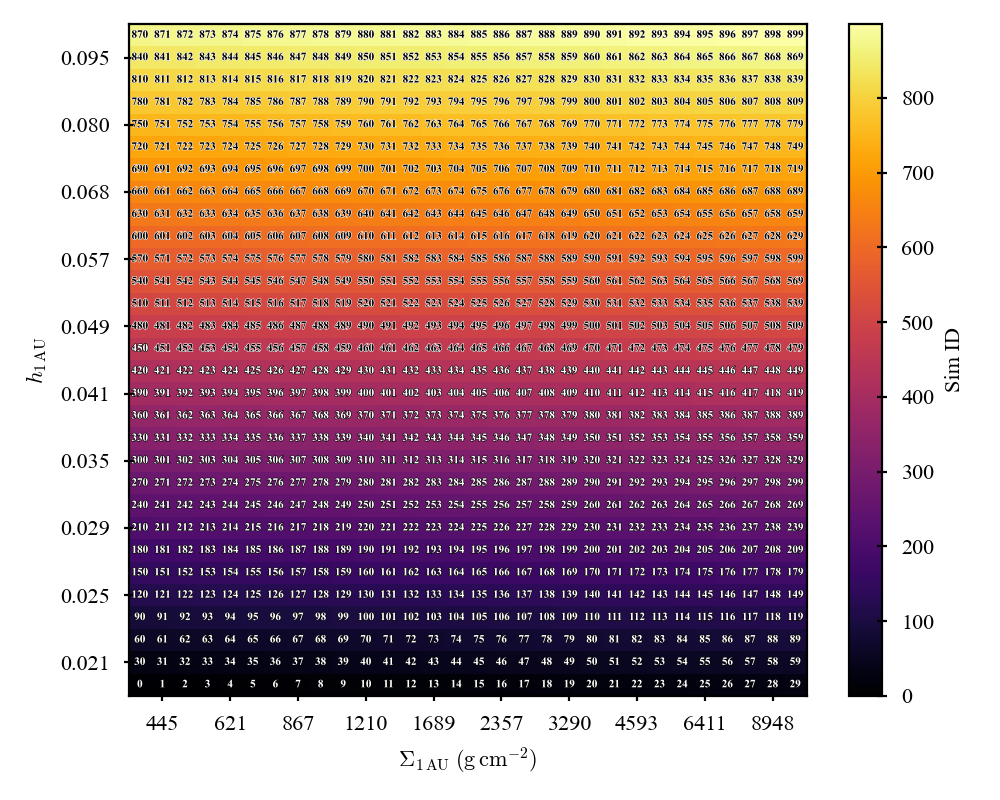

In [690]:
def plot_param_grid_map(outcomes, value_col, label, x_col="Sigma_1au", cmap='inferno', vmin=None, vmax=None, exp=False, log_cmap=False, show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=0.5, h_cut=None):
    x_vals = np.sort(outcomes[x_col].unique())
    y_vals = np.sort(outcomes["h_1au"].unique())
    
    if h_cut:
        y_vals = y_vals[y_vals <= h_cut] # specified range        
    
    # Grid
    grid = (
        outcomes
        .pivot(index=x_col,
               columns="h_1au",
               values=value_col)
        .reindex(index=x_vals,
                 columns=y_vals)
    )

    values = grid.values

    # Libration and Delta grid
    if value_col == "inner_P_ratio":
        if show_libration:
            libration_grid = (
                outcomes
                .pivot(index=x_col, columns="h_1au", values="inner_librates")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            libration_grid = None
        if show_Delta:
            Delta_grid = (
                outcomes
                .pivot(index=x_col, columns="h_1au", values="inner_P_Delta (%)")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            Delta_grid = None
    elif value_col == "outer_P_ratio":
        if show_libration:
            libration_grid = (
                outcomes
                .pivot(index=x_col, columns="h_1au", values="outer_librates")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            libration_grid = None
        if show_Delta:
            Delta_grid = (
                outcomes
                .pivot(index=x_col, columns="h_1au", values="outer_P_Delta (%)")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            Delta_grid = None
    else:
        libration_grid = None
        Delta_grid = None

    # Edges 
    x_edges = np.empty(len(x_vals)+1)
    if x_col == 'Sigma_1au':
        x_edges[1:-1] = np.sqrt(x_vals[:-1] * x_vals[1:])
        x_edges[0] = x_vals[0]**2 / x_edges[1]
        x_edges[-1] = x_vals[-1]**2 / x_edges[-2]
    elif x_col == 'log_tau_Omega':
        x_edges[1:-1] = 0.5 * (x_vals[:-1] + x_vals[1:])
        x_edges[0] = x_vals[0] - 0.5 * (x_vals[1] - x_vals[0])
        x_edges[-1] = x_vals[-1] + 0.5 * (x_vals[-1] - x_vals[-2])
    
    y_edges = np.empty(len(y_vals)+1)
    y_edges[1:-1] = np.sqrt(y_vals[:-1] * y_vals[1:])
    y_edges[0] = y_vals[0]**2 / y_edges[1]
    y_edges[-1] = y_vals[-1]**2 / y_edges[-2]
    
    # Plotting
    fig, ax = plt.subplots(figsize=(5,4))
    
    if 'survived' in value_col:
        cmap = mcolors.ListedColormap(["#482173", "#2E6F8E", "#29AF7F"])
        norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)
    else:
        cmap = plt.get_cmap(cmap).copy() # make a copy so we don't modify the global colormap
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if log_cmap else None

    cmap.set_bad("lightgray")
    
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        values.T,
        cmap=cmap,
        norm=norm,
        shading="flat",
        vmin=None if norm is not None else vmin,
        vmax=None if norm is not None else vmax,
    )

    if x_col == "Sigma_1au":
        ax.set_xlabel(r"$\Sigma_{1\,\rm AU}\;(\mathrm{g\,cm^{-2}})$")
        ax.set_xscale("log")
        ax.set_xticklabels([f"{x:.0f}" for x in x_vals][1::3]) 
        ax.set_xticks(x_vals[1::3])
    elif x_col == "log_tau_Omega":
        ax.set_xlabel(r"$\log_{10}(\tau_a \Omega)$")
        ax.set_xscale("linear")
        ax.yaxis.set_inverted(True)
        ax.set_xticklabels([f"{x:.1f}" for x in x_vals][0::7]) 
        ax.set_xticks(x_vals[::7])
    
    ax.set_ylabel(r"$h_{1\,\rm AU}$")
    ax.set_yscale("log")

     # add [1::3] for 30x30 grid
    ax.set_yticks(y_vals[1::3])
    
    ax.set_yticklabels([f"{y:.3f}" for y in y_vals][1::3])

    ax.minorticks_off()

    # Cell text
    ratios = [2/1, 5/3, 3/2, 7/5, 4/3, 5/4, 6/5, 7/6, 8/7, 1]
    for i, x in enumerate(x_vals):
        for j, y in enumerate(y_vals):

            value = values[i, j]
            if np.isnan(value):
                continue

            color = "white"
            if value > black_threshold:
                color = "k"
                
            if exp:
                disp_value = f"{value:.1e}"
            elif 'survived' in value_col:
                disp_value = f"{value:.2g}"  
            elif "%" in value_col:
                disp_value = f"{round(value)}%"
            elif "ratio" in value_col:
                frac = Fraction(value).limit_denominator()
                disp_value = f"{frac.numerator}:{frac.denominator}" if value in ratios else f"{value:.3f}" 
            elif "kyr" in value_col:
                disp_value = int(value)
            elif "id" in value_col:
                disp_value = int(value)
            else:
                disp_value = f"{value:.2f}"  
                
            if show_text:
                text = ax.text(
                    x, y,
                    disp_value,
                    ha="center",
                    va="center",
                    fontsize=4,
                    weight='bold',
                    color=color,
                    zorder=5
                )
                
                text.set_path_effects([
                    path_effects.withStroke(linewidth=0.4, foreground="black")
                ])
                if value > black_threshold:
                    text.set_path_effects([
                        path_effects.withStroke(linewidth=0.4, foreground="white")
                    ])

            if libration_grid is not None:
                if libration_grid.values[i, j]:
                    ax.annotate(
                        "L",
                        xy=(x, y),
                        xytext=(0, 1),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=5,
                        color="C3",
                        fontweight="bold"
                    )
                    
            if Delta_grid is not None:
                ax.annotate(
                    rf"$\Delta = {Delta_grid.values[i, j]}$%",
                    xy=(x, y),
                    xytext=(0, -5),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=4,
                    color=color,
                    fontweight="bold"
                )

    cbar = fig.colorbar(mesh, ax=ax)
    
    cbar.set_label(label)
        
    if 'ratio' in value_col:
        cbar.set_ticks(ratios, labels=['2:1', '5:3', '3:2', '7:5', '4:3', '5:4', '6:5', '7:6', '8:7', '1:1'])
        cbar.ax.minorticks_off()
    elif 'survived' in value_col:
        cbar.set_ticks([1,2,3])

    if show_box:                # Bottom left corner
        rect = patches.Rectangle((1352, 0.0311), width=2325, height=0.022, edgecolor='r', facecolor='none', linewidth=1, alpha=0.7, linestyle='dashed')
        ax.add_patch(rect)
            
    ax.tick_params(axis='both', direction='inout')
    cbar.ax.tick_params(direction='inout')

    plt.tight_layout()
    plt.show()

dataset_id = 6
planet_outcomes = pd.read_hdf(f"dfs/planet_outcomes{dataset_id}.h5", key="df") # Load data

# plot_param_grid_map(planet_outcomes, "pl_survived", "Number of planets remaining", vmin=1, show_text=True, show_box=False, black_threshold=3)
plot_param_grid_map(planet_outcomes, "inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", cmap='viridis', vmin=1, vmax=2, show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
plot_param_grid_map(planet_outcomes, "inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", x_col='log_tau_Omega', cmap='viridis', vmin=1, vmax=2, show_text=False, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(planet_outcomes, "outer_P_ratio", r"Outer pair period ratio ($P_d/P_c$)", cmap='viridis', vmin=1, vmax=2, show_text=True, show_libration=False, show_box=False, black_threshold=1.6, log_cmap=True)
plot_param_grid_map(planet_outcomes, "tau_a (kyr)", r"$\tau_a$ (kyr)", cmap='coolwarm', log_cmap=True, black_threshold=0)
# plot_param_grid_map(planet_outcomes, "log_tau_Omega", r"$\log(\tau_a \Omega)$", x_col='log_tau_Omega', cmap='coolwarm', log_cmap=True, show_text=False, black_threshold=0)
plot_param_grid_map(planet_outcomes, "sim_id", "Sim ID", black_threshold=450)

### Collect data on embryo and planetesimal accretion

In [517]:
def get_collision_log(metadata, max_time=None):
    """Collects collision log and converts to pd.DataFrame for later use.

    Args:
        metadata (dict): Metadata from simulation; typically comes from saved_sim[1].
        max_time (float, optional)

    Returns:
        pd.DataFrame: collision_df
    """    
    collision_df = pd.DataFrame(metadata["collision_log"])
    collision_df["time"] = collision_df["time"] / 1000  # kyr

    if max_time is not None:
        collision_df = collision_df[collision_df["time"] <= max_time]

    collision_df["time"] = collision_df["time"].round(2)
    collision_df = collision_df.rename(columns={"time": "time (kyr)"})

    collision_df["victim mass"] = (collision_df["victim mass"] / m_earth).round(4)
    collision_df = collision_df.rename(columns={"victim mass": "victim mass (m_earth)"})

    return collision_df.sort_values("time (kyr)")

def get_particle_fates(metadata, max_time):
    collision_df = get_collision_log(metadata, max_time)

    fates = {name: "alive" for name in metadata["particle_fate"]}

    for _, row in collision_df.iterrows():
        fates[row["victim"]] = "collided"

    return pd.Series(fates, name="outcome").sort_index().to_frame()

def summarize_accretion(collision_df, fates_df, percent=True):
    """Summarizes accretion information.

    Args:
        collision_df (pandas.DataFrame): DataFrame of collision log.
        percent (bool, optional): Whether to show fraction as percentage. 
            Defaults to True.

    Returns:
        pandas.DataFrame: Dataframe containing accretion summary.
    """    
    children = defaultdict(list)

    for _, row in collision_df.iterrows():
        children[row["survivor"]].append(row["victim"])

    def get_all_accreted(body):
        """Returns every particle ultimately accreted by body."""
        accreted = []

        for child in children.get(body, []):
            accreted.append(child)
            accreted.extend(get_all_accreted(child))

        return accreted

    alive_particles = [
        name
        for name, outcome in fates_df["outcome"].items()
        if outcome == "alive"
    ]

    rows = []

    for particle in alive_particles:
        accreted = get_all_accreted(particle)

        n_embryos = sum("embryo" in p for p in accreted)
        n_ptsmls = sum("ptsml" in p for p in accreted)

        rows.append({
            "particle": particle,
            "n_ems": n_embryos,
            "n_ptsmls": n_ptsmls,
            "embryo %": n_embryos / num_em,
            "ptsml %": n_ptsmls / num_ptsml,
        })

    alive_accretion_df = (pd.DataFrame(rows).set_index("particle").sort_index())

    # Keep only particles that actually accreted something
    alive_accretion_df = alive_accretion_df[
        alive_accretion_df["n_ems"] + alive_accretion_df["n_ptsmls"] > 0
    ].sort_values('n_ptsmls', ascending=False) # & sort by ptsmls accreted

    # Remaining unaccreted bodies
    n_alive_ems = num_em - alive_accretion_df["n_ems"].sum()
    n_alive_ptsmls = num_ptsml - alive_accretion_df["n_ptsmls"].sum()

    alive_accretion_df.loc["Survived"] = {
        "n_ems": n_alive_ems,
        "n_ptsmls": n_alive_ptsmls,
        "embryo %": n_alive_ems / num_em,
        "ptsml %": n_alive_ptsmls / num_ptsml,
    }

    if percent:
        # Convert to %
        alive_accretion_df["embryo %"] = (alive_accretion_df["embryo %"]*100).round(2)
        alive_accretion_df["ptsml %"] = (alive_accretion_df["ptsml %"]*100).round(2)

    return alive_accretion_df

snapshot = 20
snapshot_time = sim_data["planet b"]["time"].iloc[snapshot] / 1000  # kyr

collision_df = get_collision_log(metadata, snapshot_time)
fates_df = get_particle_fates(metadata, snapshot_time)

summary = summarize_accretion(collision_df, fates_df)
print(summary)

# Get ptsml outcomes for all sims in one dataset
def get_ptsml_outcomes(dataset_id, num_sims, snapshot=None):
    rows = []
    
    for sim_id in range(num_sims):
        base_dir = Path.cwd()
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            # print(f"Sim {sim_id} not found")
            continue
        
        sim_data, metadata = saved_sim
        
        # Get survival fraction
        if snapshot:
            snapshot_time = sim_data["planet b"]["time"].iloc[snapshot] / 1000  # kyr
        else:
            snapshot_time = None
            
        collision_df = get_collision_log(metadata, snapshot_time)
        fates_df = get_particle_fates(metadata, snapshot_time)
        summary = summarize_accretion(collision_df, fates_df)
        surv_rate = summary['ptsml %']['Survived']
        
        # Get ejection fraction
        ejec_rate = fates_df['outcome'].str.contains('ejected').sum()/len(fates_df)

        # Find median of semimajor axes of ptsmls
        a_finals = [sim_data[f'ptsml {i}']["a"].iloc[-1] for i in range(metadata['num_ptsml'])]
        a_med = np.nanmedian(a_finals)
        
        # Find median e of ptsmls
        e_finals = [sim_data[f'ptsml {i}']["e"].iloc[-1] for i in range(metadata['num_ptsml'])]
        e_med = np.nanmedian(e_finals)

        # Create df to store data
        Sigma_1au = metadata['Sigma_1au']
        h_1au = metadata['h_1au']
        
        rows.append({
            "Sigma_1au": Sigma_1au,
            "h_1au": h_1au,
            "surv_rate (%)": surv_rate,
            "ejec_rate (%)": ejec_rate,
            "ptsml a_median": a_med,
            "ptsml e_median": e_med,
        })
        
    outcomes = pd.DataFrame(rows)
    outcomes.index.name = 'sim_id'
    return outcomes

          n_ems  n_ptsmls  embryo %  ptsml %
particle                                    
planet b      4        42      40.0     42.0
embryo 2      0         1       0.0      1.0
Survived      6        57      60.0     57.0


In [249]:
ptsml_outcomes8 = get_ptsml_outcomes(dataset_id=8, num_sims=30, snapshot=None)
ptsml_outcomes8.to_hdf("dfs/ptsml_outcomes8.h5", key="df", mode="w") # Save to disk

In [ ]:
ptsml_outcomes = pd.read_hdf("dfs/ptsml_outcomes7.h5", key="df") # Load data

plot_param_grid_map(ptsml_outcomes, "surv_rate (%)", "Fraction of planetesimals remaining", cmap='coolwarm', black_threshold=0)
# plot_param_grid_map(ptsml_outcomes, "ejec_rate (%)", "Fraction of planetesimals ejected (%)")
plot_param_grid_map(ptsml_outcomes, "ptsml a_median", "Median semi-major axis of surviving planetesimals", cmap='BuPu', black_threshold=0)
plot_param_grid_map(ptsml_outcomes, "ptsml e_median", "Median eccentricity of surviving planetesimals", cmap='BuPu', black_threshold=0)

### Plot zoomed-in parameter space with binned samples

In [ ]:
def plot_binned_param_map(outcomes, value_col, label, Sigma_range=None, h_range=None, nbins=10, cmap="viridis", vmin=None, vmax=None, log_cmap=False, black_threshold=None, show_text=True, scatter=True, show_sim_id=False):

    # Parameter space limits
    if Sigma_range is None:
        Sigma_range = (
            outcomes["Sigma_1au"].min(),
            outcomes["Sigma_1au"].max()
        )

    if h_range is None:
        h_range = (
            outcomes["h_1au"].min(),
            outcomes["h_1au"].max()
        )

    # Log-spaced bin edges
    Sigma_edges = np.logspace(
        np.log10(Sigma_range[0]),
        np.log10(Sigma_range[1]),
        nbins + 1
    )

    h_edges = np.logspace(
        np.log10(h_range[0]),
        np.log10(h_range[1]),
        nbins + 1
    )

    # Bin centers for text
    Sigma_centers = np.sqrt(Sigma_edges[:-1] * Sigma_edges[1:])
    h_centers = np.sqrt(h_edges[:-1] * h_edges[1:])

    # Assign simulations to bins

    xbin = np.digitize(
        outcomes["Sigma_1au"],
        Sigma_edges
    ) - 1

    ybin = np.digitize(
        outcomes["h_1au"],
        h_edges
    ) - 1

    outcomes_binned = outcomes.copy()
    outcomes_binned["xbin"] = xbin
    outcomes_binned["ybin"] = ybin

    # Remove points outside edges
    outcomes_binned = outcomes_binned[
        (outcomes_binned["xbin"] >= 0)
        & (outcomes_binned["xbin"] < nbins)
        & (outcomes_binned["ybin"] >= 0)
        & (outcomes_binned["ybin"] < nbins)
    ]

    # Median value in each bin
    median_grid = np.full((nbins, nbins), np.nan)

    for i in range(nbins):
        for j in range(nbins):

            subset = outcomes_binned[
                (outcomes_binned["xbin"] == i)
                & (outcomes_binned["ybin"] == j)
            ]

            if len(subset) > 0:                                                              # Could also use nanmean
                median_grid[i, j] = np.nan if np.isnan(subset[value_col]).mean() > 0.5 else np.nanmedian(subset[value_col])

    # Plot
    fig, ax = plt.subplots(figsize=(5, 4))

    if 'survived' in value_col:
        cmap = mcolors.ListedColormap(["#482173", "#2E6F8E", "#29AF7F"])
        cmap.set_bad("lightgray")
        norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)
    else:
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if log_cmap else None

    mesh = ax.pcolormesh(
        Sigma_edges,
        h_edges,
        median_grid.T,
        cmap=cmap,
        shading="flat",
        norm=norm,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"$\Sigma_{1\,\rm AU}\;(\mathrm{g\,cm^{-2}})$"
    )
    ax.set_ylabel(
        r"$h_{1\,\rm AU}$"
    )
    
    ax.set_xticks(Sigma_centers)
    ax.set_yticks(h_centers)

    ax.set_xticklabels([f"{x:.0f}" for x in Sigma_centers])
    ax.set_yticklabels([f"{y:.3f}" for y in h_centers])

    ax.minorticks_off()

     # Scatter
    if scatter:
        
        if 'outer' in value_col:
            x_mask = outcomes["outer_P_ratio"].isna()
        elif 'inner' in value_col:
            x_mask = outcomes["inner_P_ratio"].isna()
        else:
            x_mask = np.full(len(outcomes), False)
            
        ax.scatter(
            outcomes.loc[x_mask, "Sigma_1au"],
            outcomes.loc[x_mask, "h_1au"],
            s=2,
            color="red",
            marker="x",
            linewidths=0.5,
            zorder=4,
            alpha=0.8
        )
        
        ax.scatter(
            outcomes.loc[~x_mask, "Sigma_1au"],
            outcomes.loc[~x_mask, "h_1au"],
            s=2,
            alpha=0.5,
            color="k",
            edgecolors="none",
            zorder=3,
            marker="D"
        )

        # Show sim_id's
        if show_sim_id:
            for _, row in outcomes.iterrows():
                ax.annotate(
                    str(int(row["sim_id"])),
                    xy=(row["Sigma_1au"], row["h_1au"]),
                    xytext=(0, -1),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=4,
                    color="k",
                    zorder=4
                )
        
    # Cell text
    ratios = [2/1, 5/3, 3/2, 7/5, 4/3, 5/4, 6/5, 7/6, 8/7, 1]
    if show_text:

        for i, x in enumerate(Sigma_centers):
            for j, y in enumerate(h_centers):

                value = median_grid[i, j]

                if np.isnan(value):
                    continue
                
                color = "white"
                
                if value > black_threshold:
                    color = "k"

                if "ratio" in value_col:
                    frac = Fraction(value).limit_denominator()
                    disp_value = f"{frac.numerator}:{frac.denominator}" if value in ratios else f"{value:.3f}"
                elif "%" in value_col:
                    disp_value = f"{value:.2g}"
                elif "survived" in value_col:
                    disp_value = f"{value:.2g}"
                else:
                    disp_value = f"{value:.2g}"

                text = ax.text(
                    x,
                    y,
                    disp_value,
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=color,
                    fontweight="bold",
                    zorder=5
                )
                
                text.set_path_effects([
                    path_effects.withStroke(linewidth=0.4, foreground="black")
                ])
                if value > black_threshold:
                    text.set_path_effects([
                        path_effects.withStroke(linewidth=0.4, foreground="white")
                    ])

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(label)
    
    ax.tick_params(axis='both', direction='inout')
    cbar.ax.tick_params(direction='inout')
    
    if 'ratio' in value_col:
        cbar.set_ticks(ratios, labels=['2:1', '5:3', '3:2', '7:5', '4:3', '5:4', '6:5', '7:6', '8:7', '1:1'])
        cbar.ax.minorticks_off()

    plt.tight_layout()
    plt.show()
 
planet_outcomes = pd.read_hdf("dfs/planet_outcomes8_c.h5", key="df") # Load data
ptsml_outcomes = pd.read_hdf("dfs/ptsml_outcomes8.h5", key="df") # Load data
   
Sigma_range = (10**(454/145), 10**(517/145))
h_range=(10**(-437/290), 10**(-187/145))

plot_binned_param_map(planet_outcomes, 'pl_survived', "Number of planets remaining", Sigma_range, h_range, show_text=True, black_threshold=4)
plot_binned_param_map(planet_outcomes, 'inner_P_ratio', r"Inner pair period ratio ($P_c/P_b$)", Sigma_range, h_range, show_sim_id=False, black_threshold=1.6, vmin=1, vmax=2, log_cmap=True)
plot_binned_param_map(planet_outcomes, 'outer_P_ratio', r"Outer pair period ratio ($P_d/P_c$)", Sigma_range, h_range, show_sim_id=False, black_threshold=1.6, vmin=1, vmax=2, log_cmap=True)
plot_binned_param_map(ptsml_outcomes, 'surv_rate (%)', "Planetesimal survival rate (%)", Sigma_range, h_range, black_threshold=0, cmap='coolwarm')

### Find simulations with inner embryos/planetesimals

In [30]:
def get_near_planet_d_sims(dataset_id, num_sims, frac=1.1):
    sim_ids = []

    for sim_id in range(num_sims):
        base_dir = Path.cwd()
        file_path = base_dir.parent/f"sim_results/dataset{dataset_id}"/f"sim{sim_id}.h5"

        try:
            sim_data, metadata = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        # Need planet d to exist
        if "planet d" not in sim_data:
            continue
        
        a_d = sim_data["planet d"]["a"].iloc[-1]

        if np.isnan(a_d):
            continue

        found = False

        for name, df in sim_data.items():

            if not (
                name.startswith("embryo")
                or name.startswith("ptsml")
            ):
                continue

            a_final = df["a"].iloc[-1]

            if np.isnan(a_final):
                continue

            if a_final <= frac * a_d:
                found = True
                break

        if found:
            sim_ids.append(sim_id)

    return sim_ids

inside_d = get_near_planet_d_sims(dataset_id=7, num_sims=900)

print(f"{len(inside_d)} simulations found")
print(inside_d)

48 simulations found
[1, 14, 15, 18, 20, 23, 24, 41, 44, 53, 54, 73, 76, 77, 80, 81, 85, 98, 103, 111, 113, 126, 140, 167, 172, 194, 198, 231, 232, 235, 240, 265, 296, 299, 305, 309, 329, 355, 357, 359, 385, 436, 470, 471, 495, 508, 566, 649]


### Plot $a$ vs. $e$ at given snapshots

In [51]:
def plot_ae_snapshot(saved_sim, *snapshot_times):
    """Plot a vs e at a one or more snapshots.
    """

    sim_data = saved_sim[0]

    # Use first body to get time array
    first_name = rock_names[0]
    times = sim_data[first_name]["time"]

    # Get idxs that best match the times given
    snapshot_idxs = np.array([
        np.argmin(np.abs(times - t))
        for t in snapshot_times
    ]) 

    num_plots = len(snapshot_times)
    fig, axs = plt.subplots(num_plots, 1, sharex=True, figsize=(4.5, 1.2 * num_plots))

    for i, ax in enumerate(axs):
        snapshot_idx = snapshot_idxs[i]
        
        # planets
        for j in range(num_pl):
            name = rock_names[j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=100,
                # label=name,
                zorder=3,
                alpha=1
            )

        # embryos
        for j in range(num_em):
            name = rock_names[num_pl + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=25,
                color='navy',
                alpha=0.75
            )

        # planetesimals
        for j in range(num_ptsml):
            name = rock_names[num_pl + num_em + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=5,
                c='k',
                alpha=0.75
            )

        if i == num_plots - 1:
            ax.set_xlabel("Semi-major axis (AU)")
        ax.set_ylim(-0.01, 0.31)
        ax.set_xlim(0.07, 2.5)
        ax.set_xscale('log')
        ax.grid(True)
        ax.set_axisbelow(True)

        t = times[snapshot_idx]
        ax.legend(title=f"t = {t/1000:.1f} kyr", title_fontsize=8, labelspacing=0)
        
    fig.supylabel('Eccentricity')
    fig.subplots_adjust(hspace=0)
    # plt.suptitle("Snapshots of Disk Evolution")
    plt.tight_layout()
    plt.show()
    # plt.savefig("disk_snapshots.svg", bbox_inches="tight")
    
end = saved_sim[0]['planet b']['time'].iloc[-1]
plot_ae_snapshot(saved_sim, 0, 6e3, end/5+50, 2*end/5+50, 3*end/5+50, 4*end/5+50)

KeyboardInterrupt: 

### Plot cumulative mass distribution of planetesimals and embryos

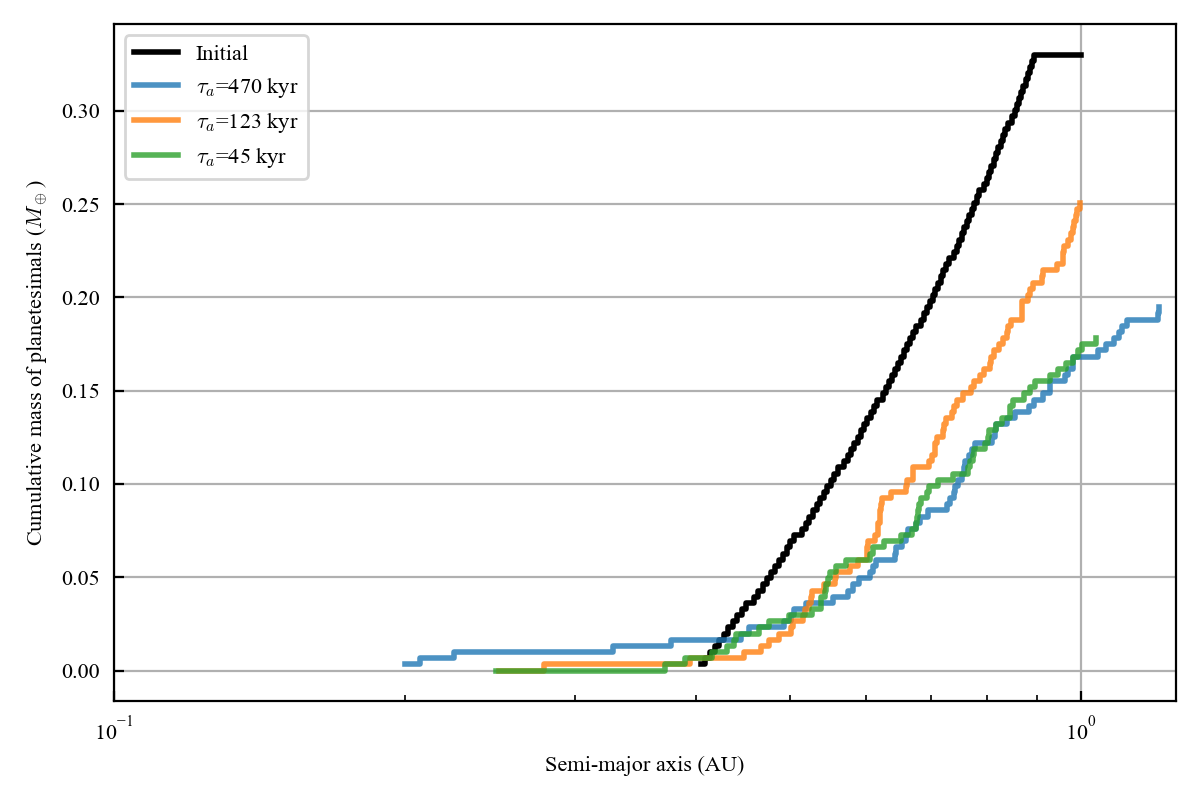

In [246]:
planet_outcomes = pd.read_hdf("dfs/planet_outcomes7_m.h5", key="df") # Load data

def plot_cumulative_mass_distribution(*sim_ids):
    """
    Plot the initial cumulative mass distribution (shared by all simulations)
    and the final distributions for each simulation.
    """

    def get_distribution(sim_data, metadata, snapshot_idx):
        a = []
        m = []

        # Planets
        for i in range(num_pl):
            name = f"planet {chr(ord('b') + i)}"

            if name not in sim_data:
                continue

            df = sim_data[name]
            if snapshot_idx >= len(df):
                continue

            aval = df["a"].iloc[snapshot_idx]
            if np.isnan(aval):
                continue

            a.append(aval)
            m.append(metadata["m_vals"][i + 1])   # skip star

        # Embryos
        # for i in range(num_em):
        #     name = f"embryo {i}"

        #     if name not in sim_data:
        #         continue

        #     df = sim_data[name]
        #     if snapshot_idx >= len(df):
        #         continue

        #     aval = df["a"].iloc[snapshot_idx]
        #     if np.isnan(aval):
        #         continue

        #     a.append(aval)
        #     metadata["m_em"] = 0.03
        #     m.append(metadata["m_em"])

        # Planetesimals
        for i in range(num_ptsml):
            name = f"ptsml {i}"

            if name not in sim_data:
                continue

            df = sim_data[name]
            if snapshot_idx >= len(df):
                continue

            aval = df["a"].iloc[snapshot_idx]
            if np.isnan(aval):
                continue

            a.append(aval)
            m.append(metadata["m_ptsml"])

        a = np.asarray(a)
        m = np.asarray(m)

        order = np.argsort(a)

        return a[order], np.cumsum(m[order])

    plt.figure(figsize=(6, 4))

    base_dir = Path.cwd()
    file_paths = [base_dir.parent / f"sim_results/dataset7" / f"sim{sim_id}.h5" for sim_id in sim_ids]
    saved_sims = [reb_sims.load_simulation_run(file_path) for file_path in file_paths]
    
    # Plot initial state once
    sim_data, metadata = saved_sims[0]
    a0, M0 = get_distribution(sim_data, metadata, 0)
    plt.step(a0, M0, where="post", lw=2, color="k", label="Initial")

    # Plot each final state
    for i, (sim_data, metadata) in enumerate(saved_sims):
        end_idx = len(sim_data["planet b"]) - 1
        end_idx=20
        af, Mf = get_distribution(sim_data, metadata, end_idx)

        plt.step(
            af,
            Mf,
            where="post",
            lw=2,
            alpha=0.8,
            label=rf"$\tau_a$={int(planet_outcomes.iloc[sim_ids[i]]['tau_a (kyr)'])} kyr"
        )

    plt.xlim(0.1)
    plt.xscale("log")
    plt.xlabel("Semi-major axis (AU)")
    plt.ylabel("Cumulative mass of planetesimals ($M_\\oplus$)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    
sim_ids = [188, 76, 54]
plot_cumulative_mass_distribution(*sim_ids)

### Plot libration of the resonance angle $\phi$

True period ratio: 1.3334
p, q: 4, 3
Libration amplitude: 16.3 deg


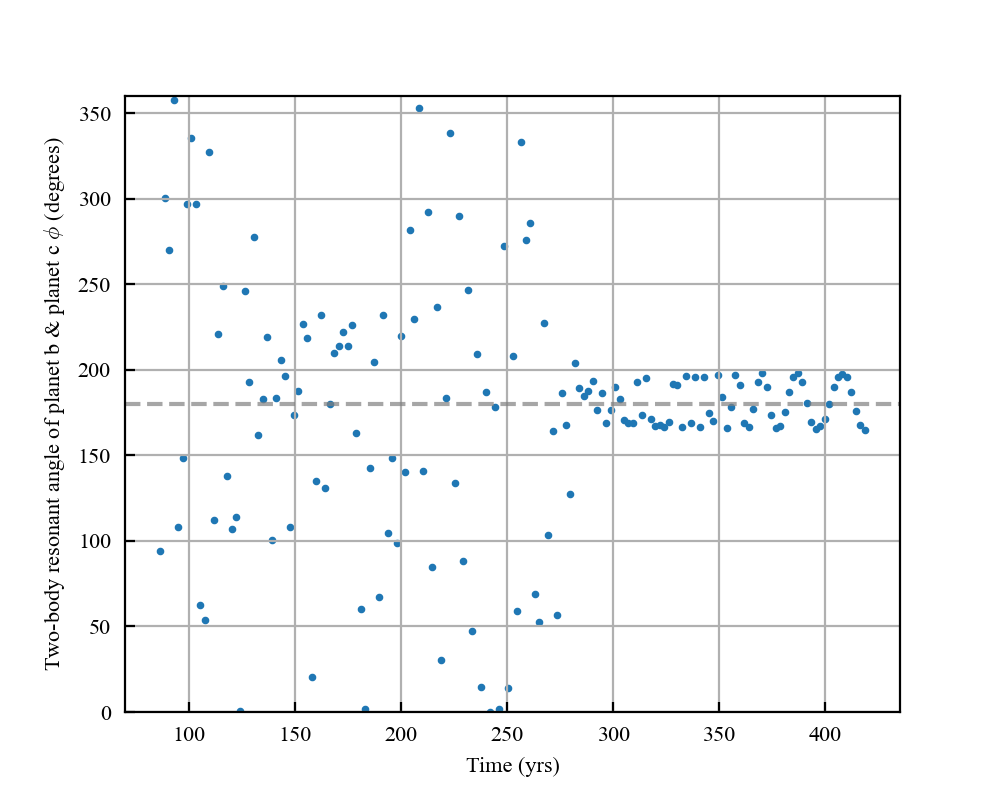

True period ratio: 1.5016
p, q: 3, 2
Libration amplitude: 18.5 deg


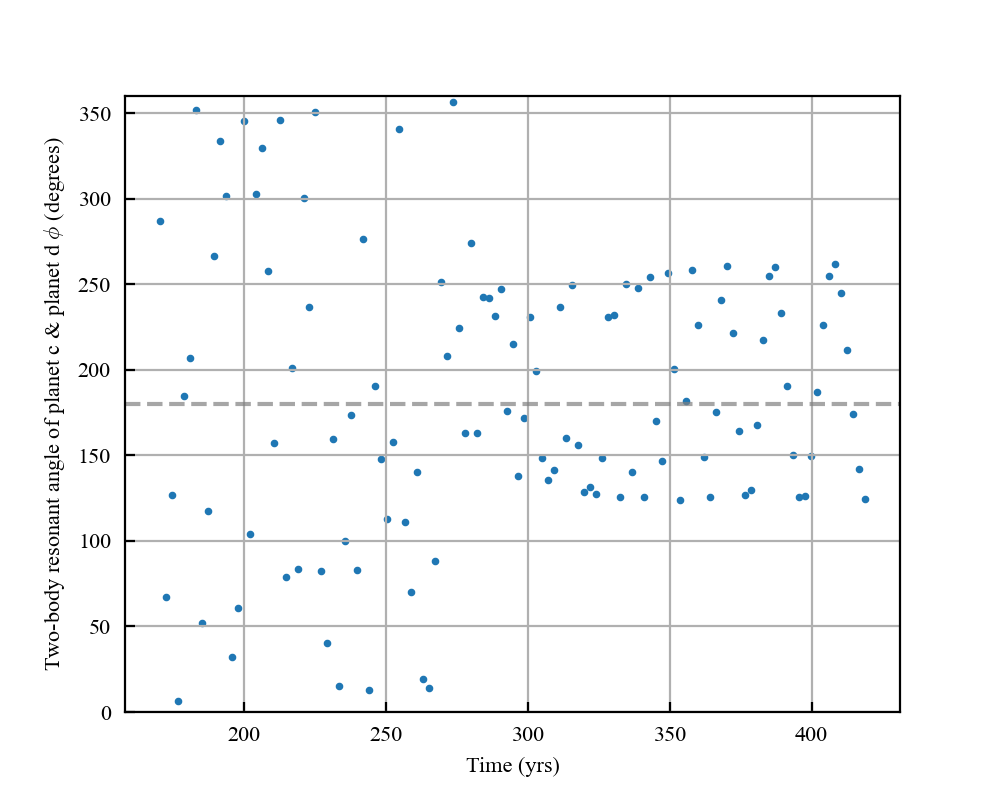

In [695]:
mmr_id.plot_libration(m_star, rocks['planet b'], rocks['planet c'], pomega='mixed', forced_pq=None)
mmr_id.plot_libration(m_star, rocks['planet c'], rocks['planet d'], pomega='mixed', forced_pq=None)

### Calculate overstability criterion

In [742]:
# Obtain timescales

from timescales import tau_t1_mig, tau_gas

# === PARAMETERS ===
planets = {
    "name": ['planet b', 'planet c', 'planet d'],
    "m_vals": [4, 8, 5], # [m_earth]
    "a_vals": [0.107, 0.2, 0.3], # [AU]
    "r_vals": [10, 10, 10] # [r_earth]; twice the current values
}

num_pl = 3
num_em = 1
num_ptsml = 1

rock_names = planets['name'][:num_pl] + [f"embryo {i}" for i in range(num_em)] + [f"ptsml {i}" for i in range(num_ptsml)]
    
# Setting up em/ptsml disk
m_em = 0.03 # [m_earth]
r_em = 0.3 # [r_earth]
m_ptsml = 0.0033 # [m_earth]
r_ptsml = (100*1e5/AU)/r_earth # 100 km in [r_earth]
small_body_a_vals = np.linspace(0.4, 0.9, num_em+num_ptsml) # equally spaced locations in disk range
em_indices = np.round(np.linspace(0, len(small_body_a_vals) - 1, num=num_em)).astype(int) # picks num_em equally spaced indices
em_a_vals = small_body_a_vals[em_indices]
ptsml_a_vals = np.delete(small_body_a_vals, em_indices)
    
# Combine values for planets, ems, ptsmls
m_vals = np.array(planets['m_vals'][:num_pl] + [m_em]*num_em + [m_ptsml]*num_ptsml) * m_earth
r_vals = np.array(planets['r_vals'][:num_pl] + [r_em]*(num_em) + [r_ptsml]*num_ptsml) * r_earth
m_star = 1. # Msun
r_star = 1.5 * r_sun
a_vals = np.concatenate((planets['a_vals'][:num_pl], em_a_vals, ptsml_a_vals)) # Initial a_vals
    
# Full parameter space
Sigma_1au = 1700
h_1au = 0.03
alpha = 1
beta = 0                                  # Converted to Msun/AU^2 from g/cm^2
tau_a = 1/(2.7+1.1*alpha) / m_vals[0] / (Sigma_1au*AU**2 / Msun) * h_1au**2 / (2*np.pi) # for a = 1

parameters = {"m_vals": m_vals,
              "m_star": m_star,
              "r_vals": r_vals,
              "r_star": r_star,
              "a_vals": a_vals,
              "num_pl": num_pl,
              "num_em": num_em,
              "num_ptsml": num_ptsml,
              "ide_position": 0.1,
              "ide_width": 0.1 * h_1au**beta,
              "Sigma_1au": Sigma_1au,
              "h_1au": h_1au,
              "alpha": alpha,
              "beta": beta,
              "m_em": m_em,
              "r_em": r_em,
              "m_ptsml": m_ptsml,
              "r_ptsml": r_ptsml,
            } 

import rebound
# Create the simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')
sim.add(m=parameters["m_star"], r=parameters["r_star"], hash='star')

# Add planet 1
sim.add(
    m=parameters['m_vals'][0], 
    r=parameters['r_vals'][0], 
    a=parameters['a_vals'][0], 
    primary=sim.particles[0], 
    e=0,
    inc=0,
)

# Add planet 2
sim.add(
    m=parameters['m_vals'][1], 
    r=parameters['r_vals'][1], 
    a=parameters['a_vals'][1], 
    primary=sim.particles[0], 
    e=0,
    inc=0,
)

# Add ptsml
sim.add(
    m=parameters['m_vals'][-1], 
    r=parameters['r_vals'][-1], 
    a=parameters['a_vals'][-1], 
    primary=sim.particles[0], 
    e=0,
    inc=0,
)

ps = sim.particles
ta_p1, te_p1 = -np.array(tau_t1_mig(ps[1], parameters))[0:2]
ta_p2, te_p2 = -np.array(tau_t1_mig(ps[2], parameters))[0:2]
ta_ptsml, te_ptsml = -np.array(tau_gas(ps[-1], parameters))[0:2]
print('planet 1', int(ta_p1), int(te_p1))
print('planet 2', int(ta_p2), int(te_p2))
print('ptsml   ', int(ta_ptsml), int(te_ptsml))

planet 1 13392 23
planet 2 3667 16
ptsml    815668400124 1303918092


In [741]:
def get_crit_ep(k, Sigma_1au, h_1au):
    # Batygin: k:k-1, so 7:6 MMR has k=7
    # Deck: m+1:m, so 7:6 MMR has m=6
    m = k-1
    print(f"{k}:{k-1} MMR")

    B = 0.8*m
    p = 1 # coupling parameter

    m1 = m_ptsml*m_earth
    m2 = 5*m_earth
    zeta = m1/m2
    print(f"zeta: {zeta:.5f}")

    alpha = 1
    print(f"Sigma_1au: {Sigma_1au}, h_1au: {h_1au}")

    chi_a = 1/(2.7+1.1*alpha)
    chi_e = 1/0.780

    alphares = ((k-1)/k)**(2/3)
    print(f"α_res: {alphares:.3f}")
    with open("fg_library.pkl", "rb") as f:
        fg_lib = pkl.load(f)

    f, g = fg_lib[(k, k-1)]

    R = abs(f)/g # if not 2:1

    # Change these
    ta1, te1 = ta_p1, te_p1 # ta_ptsml, te_ptsml # inner
    ta2, te2 = ta_p2, te_p2       # outer

    ta = (1/ta2 - 1/ta1)**-1
    te = (1/te1 + zeta/te2)**-1
    tae = (1/te1 - zeta**2 * alphares / (R**2 * te2))**-1 

    ep_p = m1+m2
    ep_p_crit = (3*p*m)/(B * 2**1.5) * te/tae * (1+zeta)**2 / (m*(zeta+1) + p*te/tae)**1.5 * (te/ta)**1.5
    print(f"ε_p: {ep_p:.4g}") # Overstable if over ep_p_crit
    print(f"ε_p,crit: {ep_p_crit:.4g}") 
    if ep_p < ep_p_crit:
        print("ep_p < ep_p_crit")
    else:
        print("ep_p > ep_p_crit")
        
get_crit_ep(4, 1700, 0.03)

4:3 MMR
zeta: 0.00066
Sigma_1au: 1700, h_1au: 0.03
α_res: 0.825
ε_p: 1.503e-05
ε_p,crit: 1.28e-05
ep_p > ep_p_crit


In [733]:
print(f"ta1 = {ta1:.3e}")
print(f"ta2 = {ta2:.3e}")
print(f"ta  = {ta:.3e}")

print(f"te1 = {te1:.3e}")
print(f"te2 = {te2:.3e}")
print(f"te  = {te:.3e}")

print(f"tae = {tae:.3e}")

print(f"te/ta  = {te/ta:.3e}")
print(f"te/tae = {te/tae:.3e}")

ta1 = 8.396e+11
ta2 = 1.071e+04
ta  = 1.071e+04
te1 = 1.336e+09
te2 = 1.882e+01
te  = 2.851e+04
tae = -2.893e+07
te/ta  = 2.661e+00
te/tae = -9.853e-04


In [822]:
def batygin26_instab(k, zeta, m2, h, alpha):
    # k:k-1 MMR
    chi_a = 1/(2.7+1.1*alpha)
    chi_e = 1/0.780
    lhs = (zeta*(k*(1+zeta)-2*zeta) / (1-zeta) * chi_a/chi_e)**(3/2)
    rhs = 15/32 * (1-zeta**2) / (m2) * h**3
    # print(f"{lhs:.3g}, {rhs:.3g}")
    if lhs < rhs: # If this holds, then the system IS overstable
        return True
    else:
        return False

alpha = 3/5
m1 = 4*m_earth # inner
m2 = 8*m_earth # outer
zeta = m1/m2

for h in np.linspace(0.01, 0.1, 7):
    print(f"h: {h:.2f}")
    print(batygin26_instab(6, zeta, m2, h, alpha))
    print()

h: 0.01
False

h: 0.03
False

h: 0.04
False

h: 0.06
False

h: 0.07
True

h: 0.09
True

h: 0.10
True



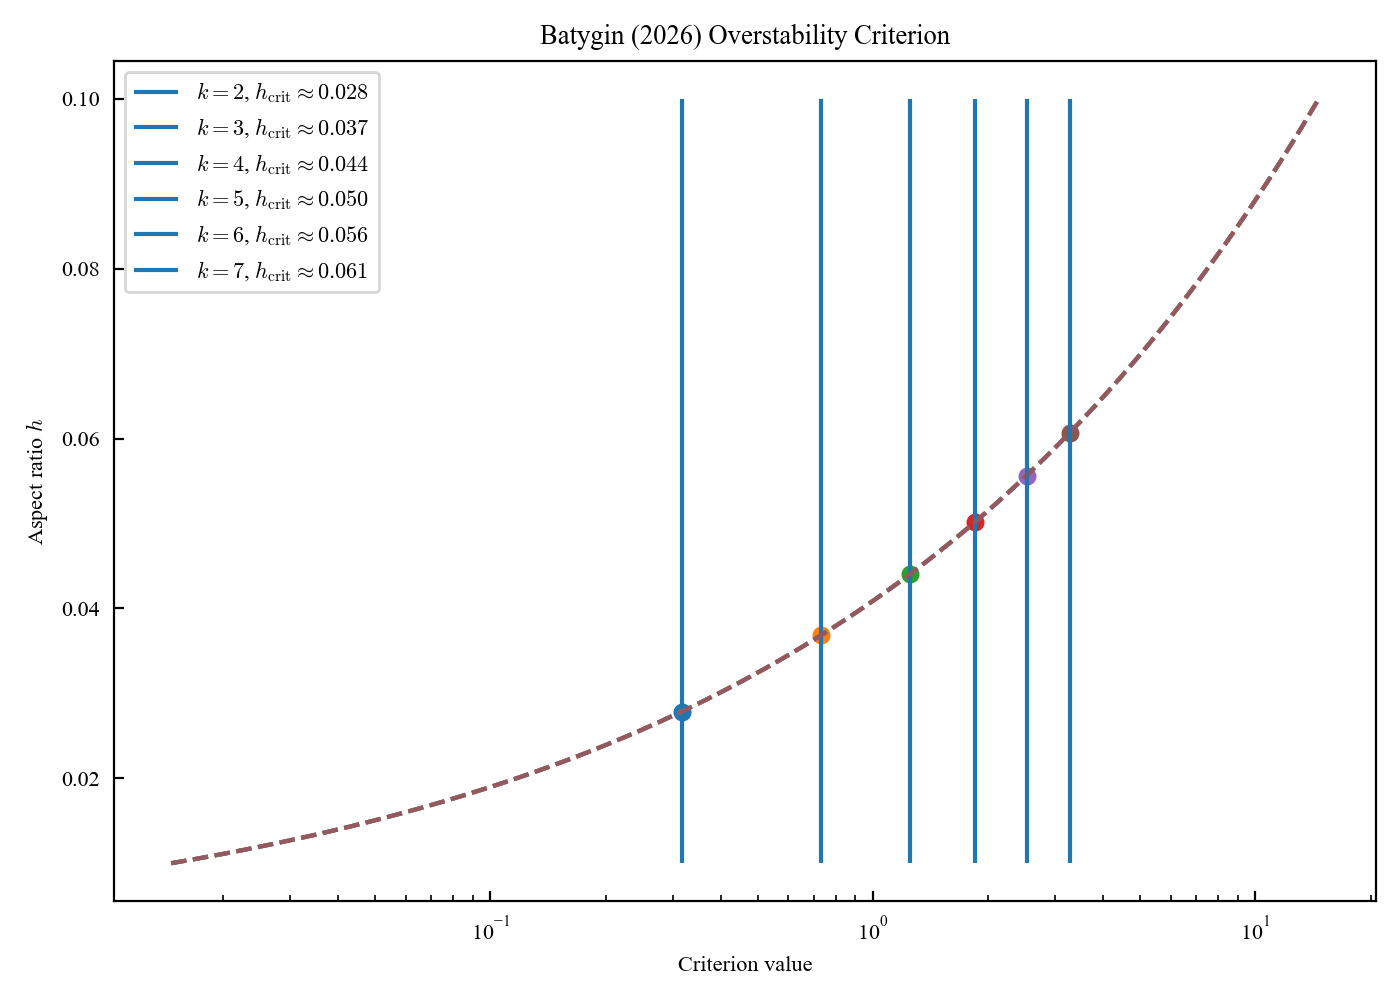

In [837]:
def chi_a(alpha=0):
    return 1/(2.7 + 1.1*alpha)

def chi_e():
    return 1/0.780

def lhs_func(k, zeta, alpha=0):
    coeff = (
        zeta * (k*(1+zeta) - 2*zeta) / (1-zeta)
        * (chi_a(alpha) / chi_e())
    )
    return coeff**1.5

def rhs_func(m2, zeta, h):
    return (15/32) * (1 - zeta**2) / m2 * h**3

# system setup
m1 = 4 * m_earth
m2 = 8 * m_earth
zeta = m1 / m2

k_vals = np.arange(2, 8)
h_vals = np.linspace(0.01, 0.10, 500)

plt.figure(figsize=(7,5))

for k in k_vals:
    lhs = lhs_func(k, zeta, alpha=3/5)
    rhs_vals = rhs_func(m2, zeta, h_vals)

    # instability condition: lhs < rhs
    unstable = rhs_vals > lhs

    # find transition point (approx where sign flips)
    idx = np.argmin(np.abs(rhs_vals - lhs))
    h_crit = h_vals[idx]

    plt.plot(rhs_vals, h_vals, linestyle='--', alpha=0.6)
    plt.vlines(lhs, h_vals.min(), h_vals.max(),
               label=rf'$k={k}$, $h_{{\rm crit}} \approx {h_crit:.3f}$')

    # mark transition
    plt.scatter(lhs, h_crit, s=30)

plt.xscale('log')
plt.ylabel(r'Aspect ratio $h$')
plt.xlabel('Criterion value')
plt.title('Batygin (2026) Overstability Criterion')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
ta


np.float64(10713.702279223202)

In [ ]:
K1 = ta/te1
K2 = ta/te2
1/(ta_Omega) < 5*np.pi/8 * (5/(36 * k**5 * (k-1)**(2/3)))**(1/3) * (1/(m1+m2))**(4/3) # if holds, resonance capture is possible
1/(ta_Omega) < m2/1 * np.sqrt(32 * k**3 * (1+zeta) * (zeta*K1+K2) / (25*K1*K2)) # dissipative stability criterion

np.float64(22396.718258610723)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# parameters (edit as needed)
# -----------------------------
k = 7
m_earth = 3.003e-6
m1 = 4 * m_earth
m2 = 8 * m_earth
zeta = m1 / m2

# grids
logX = np.linspace(4, 6, 300)          # log10(tau_a * Omega)
logK = np.linspace(0.5, 3.5, 300)

X = 10**logX
K1_grid, X_grid = np.meshgrid(10**logK, X)

# assume K2 grid identical for plotting symmetry
K2_grid = K1_grid.copy()

# -----------------------------
# functions
# -----------------------------

def adiabatic_threshold(k, zeta, m1, m2):
    return (5*np.pi/8) * (5/(36*k**5*(k-1)**(2/3)))**(1/3) * (1/(m1+m2))**(4/3)

def dissipative_threshold(k, zeta, m2, K1, K2):
    return (m2) * np.sqrt(
        32 * k**3 * (1+zeta) * (zeta*K1 + K2) / (25*K1*K2)
    )

A = adiabatic_threshold(k, zeta, m1, m2)

# condition 1: adiabatic capture
adiabatic = (1/X_grid) < A

# condition 2: dissipative stability
diss = (1/X_grid) < dissipative_threshold(k, zeta, m2, K1_grid, K2_grid)

# combined regimes
capture_only = adiabatic & (~diss)
stable_resonance = adiabatic & diss
no_capture = ~adiabatic

# -----------------------------
# plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7,6))

# color regions
ax.contourf(
    np.log10(X_grid),
    np.log10(K1_grid),
    stable_resonance.astype(int),
    levels=[-0.5,0.5,1.5],
    alpha=0.5,
    colors=["white","green"]
)

ax.contourf(
    np.log10(X_grid),
    np.log10(K1_grid),
    capture_only.astype(int),
    levels=[-0.5,0.5,1.5],
    alpha=0.5,
    colors=["orange","orange"]
)

ax.contourf(
    np.log10(X_grid),
    np.log10(K1_grid),
    no_capture.astype(int),
    levels=[-0.5,0.5,1.5],
    alpha=0.3,
    colors=["gray","gray"]
)

ax.set_xlabel(r'$\log_{10}(\tau_a \Omega)$')
ax.set_ylabel(r'$\log_{10}(K_1)$')
ax.set_title(f'Resonance Stability Map (k={k})')

# -----------------------------
# secondary y-axis for K2
# -----------------------------
ax2 = ax.twinx()
ax2.set_ylabel(r'$\log_{10}(K_2)$')
ax2.set_ylim(ax.get_ylim())

plt.tight_layout()
plt.show()

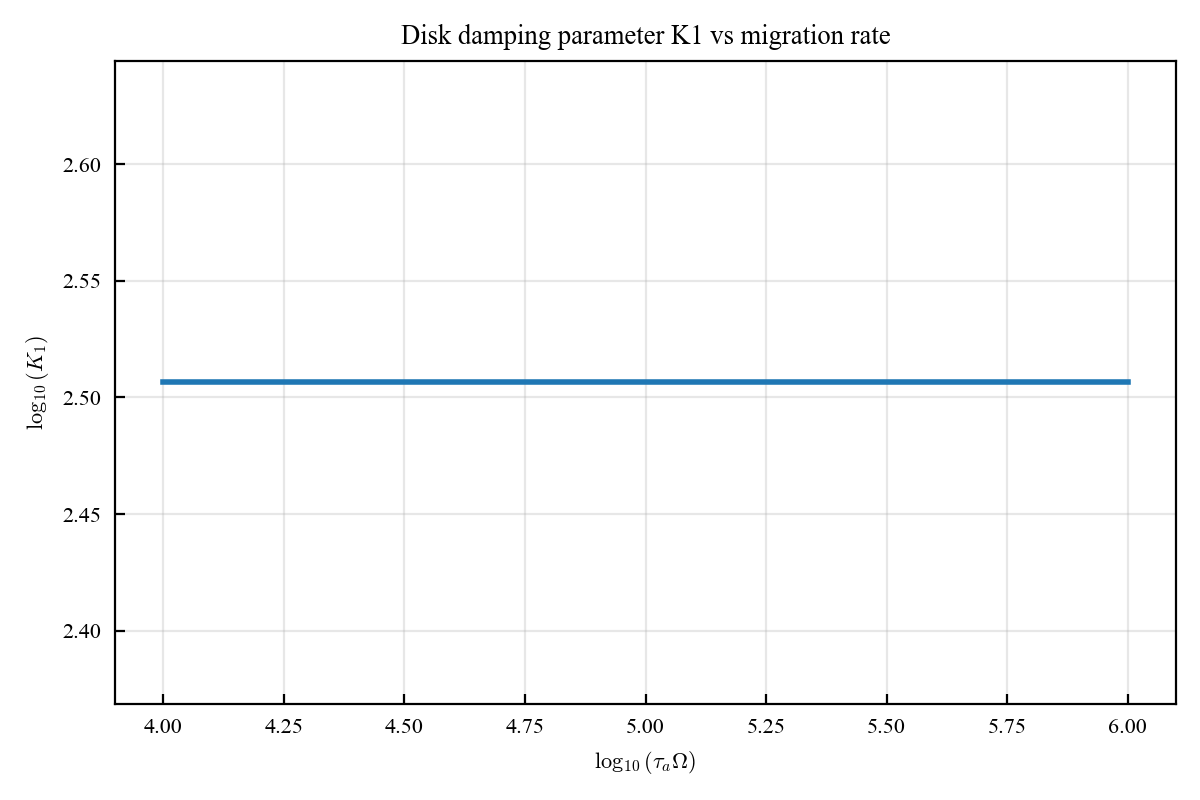

In [840]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# constants
# -----------------------
s = 0  # surface density slope
h = 0.03

C = 0.78 / (2.7 + 1.1*s)

# -----------------------
# grid: tau_a * Omega
# -----------------------
log_tauOmega = np.linspace(4, 6, 400)
tauOmega = 10**log_tauOmega

# -----------------------
# model: K1 definition
# -----------------------
# K1 = tau_a / tau_e1
# tau_e1 = (2.7+1.1s)/0.78 * h^2 * tau_a1

# assume tau_a = tau_a1 (standard nondimensional Batygin-style scaling)
K1 = C / (h**2) * np.ones_like(tauOmega)

# -----------------------
# plot
# -----------------------
plt.figure(figsize=(6,4))

plt.plot(log_tauOmega, np.log10(K1), lw=2)

plt.xlabel(r'$\log_{10}(\tau_a \Omega)$')
plt.ylabel(r'$\log_{10}(K_1)$')
plt.title('Disk damping parameter K1 vs migration rate')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [841]:
with open("fg_library.pkl", "rb") as f:
        fg_lib = pkl.load(f)

f, g = fg_lib[(2,1)]
print(f,g)

-1.1904936978495033 0.428389834143899
